In [7]:
import pandas as pd
import numpy as np
import pydicom
import cv2
import matplotlib.pyplot as plt
import os
import torchvision.transforms.functional as TF
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision

In [2]:
LABELS_PATH = r"C:\Users\Arush\Downloads\stage_2_train_labels.csv\stage_2_train_labels.csv"
IMAGE_DIR = r"C:\Users\Arush\Downloads\stage_2_train_images"

labels = pd.read_csv(LABELS_PATH)

print("Total rows:", len(labels))
labels.head()

Total rows: 30227


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [3]:
print(labels["Target"].value_counts())

all_ids = labels["patientId"].unique()
print("Total patients:", len(all_ids))

Target
0    20672
1     9555
Name: count, dtype: int64
Total patients: 26684


In [4]:
def get_boxes(patient_id):
    records = labels[labels['patientId'] == patient_id]

    boxes = []
    for _, row in records.iterrows():
        if row['Target'] == 1:
            x1 = row['x']
            y1 = row['y']
            x2 = x1 + row['width']
            y2 = y1 + row['height']
            boxes.append([x1, y1, x2, y2])

    return boxes

In [5]:
def load_image(path):
    dicom = pydicom.dcmread(path)
    img = dicom.pixel_array

    orig_h, orig_w = img.shape

    img = cv2.resize(img, (512, 512))
    img = img / 255.0

    return img, (orig_w, orig_h)

In [6]:
def show_image_with_boxes(patient_id):
    path = os.path.join(IMAGE_DIR, f"{patient_id}.dcm")

    img, (orig_w, orig_h) = load_image(path)
    boxes = get_boxes(patient_id)

    scale_x = 512 / orig_w
    scale_y = 512 / orig_h

    img_copy = img.copy()

    for box in boxes:
        x1, y1, x2, y2 = box

        x1 = int(x1 * scale_x)
        x2 = int(x2 * scale_x)
        y1 = int(y1 * scale_y)
        y2 = int(y2 * scale_y)

        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (1, 0, 0), 2)

    plt.imshow(img_copy, cmap='gray')
    plt.title(f"Patient ID: {patient_id}")
    plt.axis("off")
    plt.show()

In [8]:
class RSNADataset(Dataset):
    def __init__(self, image_dir, labels_df, image_ids, augment=False):
        self.image_dir = image_dir
        self.labels_df = labels_df
        self.image_ids = image_ids
        self.augment   = augment

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        patient_id = self.image_ids[idx]
        path = os.path.join(self.image_dir, f"{patient_id}.dcm")
        dicom = pydicom.dcmread(path)
        img = dicom.pixel_array.astype(np.float32)

        orig_h, orig_w = img.shape
        img = cv2.resize(img, (512, 512))
        img = img / 255.0

        # Fix: Faster R-CNN expects 3-channel (RGB) input
        img_t = torch.tensor(img).unsqueeze(0).repeat(3, 1, 1)  # (3, 512, 512)

        records = self.labels_df[self.labels_df["patientId"] == patient_id]
        boxes = []
        for _, row in records.iterrows():
            if row["Target"] == 1:
                x1 = row["x"] * (512 / orig_w)
                y1 = row["y"] * (512 / orig_h)
                x2 = (row["x"] + row["width"])  * (512 / orig_w)
                y2 = (row["y"] + row["height"]) * (512 / orig_h)
                boxes.append([x1, y1, x2, y2])

        if len(boxes) == 0:
            boxes_t  = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,),   dtype=torch.int64)
        else:
            boxes_t  = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.ones((len(boxes),), dtype=torch.int64)

        # Data augmentation (Improvement technique #2)
        if self.augment and len(boxes_t) > 0:
            # Random horizontal flip
            if random.random() > 0.5:
                img_t = TF.hflip(img_t)
                boxes_t[:, [0, 2]] = 512 - boxes_t[:, [2, 0]]

            # Random brightness / contrast jitter
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                img_t = torch.clamp(img_t * factor, 0.0, 1.0)

            # Random small rotation (±10 degrees) using affine
            if random.random() > 0.5:
                angle = random.uniform(-10, 10)
                img_t = TF.rotate(img_t, angle)

        target = {"boxes": boxes_t, "labels": labels_t}
        return img_t, target


In [9]:
pos_ids = labels[labels["Target"] == 1]["patientId"].unique()
neg_ids = labels[labels["Target"] == 0]["patientId"].unique()

pos_sample = np.random.choice(pos_ids, 1000, replace=False)
neg_sample = np.random.choice(neg_ids, 1000, replace=False)

selected_ids = list(pos_sample) + list(neg_sample)

In [10]:
from sklearn.model_selection import train_test_split

train_ids, val_ids = train_test_split(selected_ids, test_size=0.2)

print(len(train_ids), len(val_ids))

1600 400


In [11]:
pos_ids = labels[labels["Target"] == 1]["patientId"].unique()
neg_ids = labels[labels["Target"] == 0]["patientId"].unique()

pos_sample = np.random.choice(pos_ids, 1000, replace=False)
neg_sample = np.random.choice(neg_ids, 1000, replace=False)

selected_ids = list(pos_sample) + list(neg_sample)

In [12]:
from sklearn.model_selection import train_test_split

train_ids, val_ids = train_test_split(selected_ids, test_size=0.2)

print(len(train_ids), len(val_ids))

1600 400


In [13]:
train_dataset = RSNADataset(IMAGE_DIR, labels, train_ids, augment=True)  # augmentation ON
val_dataset   = RSNADataset(IMAGE_DIR, labels, val_ids,   augment=False) # no augmentation for val


In [14]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

In [15]:
images, targets = next(iter(train_loader))

print(len(images))
print(images[0].shape)
print(targets[0])

4
torch.Size([3, 512, 512])
{'boxes': tensor([[ 95.5000, 131.0000, 206.5000, 336.0000]]), 'labels': tensor([1])}


In [16]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)

num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)


In [17]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model.to(device)

print("Using:", device)
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

Using: cuda
NVIDIA GeForce RTX 4050 Laptop GPU
True


In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


Epoch 1/5  Train Loss: 70.3739  Val Loss: 15.5042
Epoch 2/5  Train Loss: 67.9052  Val Loss: 16.2578
Epoch 3/5  Train Loss: 66.3740  Val Loss: 16.6009
Epoch 4/5  Train Loss: 63.1328  Val Loss: 15.3686
Epoch 5/5  Train Loss: 60.5228  Val Loss: 15.4341


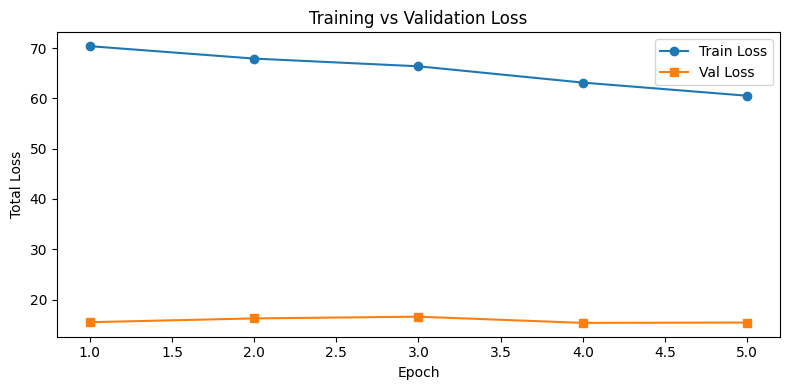

In [20]:
num_epochs = 5
train_losses = []
val_losses   = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for images, targets in train_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    model.train()
    total_val_loss = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            total_val_loss += sum(loss_dict.values()).item()

    lr_scheduler.step()

    train_losses.append(total_train_loss)
    val_losses.append(total_val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}  "
          f"Train Loss: {total_train_loss:.4f}  "
          f"Val Loss: {total_val_loss:.4f}")

# Plot training vs validation loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses,   marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter_area = max(0, xB - xA) * max(0, yB - yA)

    box1_area = (box1[2]-box1[0]) * (box1[3]-box1[1])
    box2_area = (box2[2]-box2[0]) * (box2[3]-box2[1])

    return inter_area / (box1_area + box2_area - inter_area + 1e-6)

In [22]:
model.eval()

iou_scores = []

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]

        outputs = model(images)

        for i in range(len(images)):
            preds = outputs[i]["boxes"].cpu().numpy()
            gts = targets[i]["boxes"].numpy()

            for gt in gts:
                best_iou = 0
                for pred in preds:
                    iou = compute_iou(pred, gt)
                    best_iou = max(best_iou, iou)

                iou_scores.append(best_iou)

In [23]:
mean_iou = sum(iou_scores) / len(iou_scores)
print("Mean IoU:", mean_iou)

Mean IoU: 0.6426325


In [26]:
all_scores = []
all_tp = []
total_gt = 0

model.eval()

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for i in range(len(images)):
            preds = outputs[i]["boxes"].cpu().numpy()
            scores = outputs[i]["scores"].cpu().numpy()
            gts = targets[i]["boxes"].numpy()

            total_gt += len(gts)

            matched = set()

            for pred, score in zip(preds, scores):
                best_iou = 0
                best_idx = -1

                for j, gt in enumerate(gts):
                    iou = compute_iou(pred, gt)
                    if iou > best_iou:
                        best_iou = iou
                        best_idx = j

                if best_iou >= 0.5 and best_idx not in matched:
                    all_tp.append(1)
                    matched.add(best_idx)
                else:
                    all_tp.append(0)

                all_scores.append(score)

In [ ]:
if len(all_scores) == 0 or total_gt == 0:
    print("No predictions or ground-truth boxes found.")
    mAP = 0.0
else:
    indices = np.argsort(-np.array(all_scores))
    tp = np.array(all_tp)[indices]
    fp = 1 - tp

    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)

    precision = tp_cum / (tp_cum + fp_cum + 1e-6)
    recall    = tp_cum / (total_gt + 1e-6)

    for i in range(len(precision) - 2, -1, -1):
        precision[i] = max(precision[i], precision[i + 1])

    mAP = np.trapezoid(precision, recall)
    print("mAP at IoU=0.5:", mAP)


mAP at IoU=0.5: 0.4294360744066119


C:\Users\Arush\AppData\Local\Temp\ipykernel_30576\1815693379.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mAP = np.trapz(precision, recall)


In [ ]:
#baseline comparison

In [27]:
baseline_train_dataset = RSNADataset(IMAGE_DIR, labels, train_ids, augment=False)
baseline_val_dataset   = RSNADataset(IMAGE_DIR, labels, val_ids,   augment=False)
baseline_train_loader  = DataLoader(baseline_train_dataset, batch_size=4, shuffle=True,  collate_fn=collate_fn)
baseline_val_loader    = DataLoader(baseline_val_dataset,   batch_size=4, shuffle=False, collate_fn=collate_fn)

baseline_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
in_features_b  = baseline_model.roi_heads.box_predictor.cls_score.in_features
baseline_model.roi_heads.box_predictor = FastRCNNPredictor(in_features_b, 2)
baseline_model.to(device)

baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-4)

print("Training baseline model")
for epoch in range(3):
    baseline_model.train()
    total_loss = 0
    for imgs, tgts in baseline_train_loader:
        imgs = [i.to(device) for i in imgs]
        tgts = [{k: v.to(device) for k, v in t.items()} for t in tgts]
        loss_dict = baseline_model(imgs, tgts)
        loss = sum(loss_dict.values())
        baseline_optimizer.zero_grad()
        loss.backward()
        baseline_optimizer.step()
        total_loss += loss.item()
    print(f"  Baseline Epoch {epoch+1}/3  Loss: {total_loss:.4f}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Arush/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:26<00:00, 3.80MB/s]


Training baseline model (3 epochs, no pretrained weights, no augmentation)...
  Baseline Epoch 1/3  Loss: 79.4685
  Baseline Epoch 2/3  Loss: 72.4135
  Baseline Epoch 3/3  Loss: 66.3007


Evaluating baseline model...
Evaluating improved model...

Metric                          Baseline       Improved
----------------------------------------------------------
Mean IoU                          0.6260         0.6426
mAP @ IoU=0.5                     0.3551         0.4294
Pretrained weights                    No            Yes
Data augmentation                     No            Yes
LR scheduler                          No         StepLR

Improvement -> IoU: +0.0167  |  mAP: +0.0744


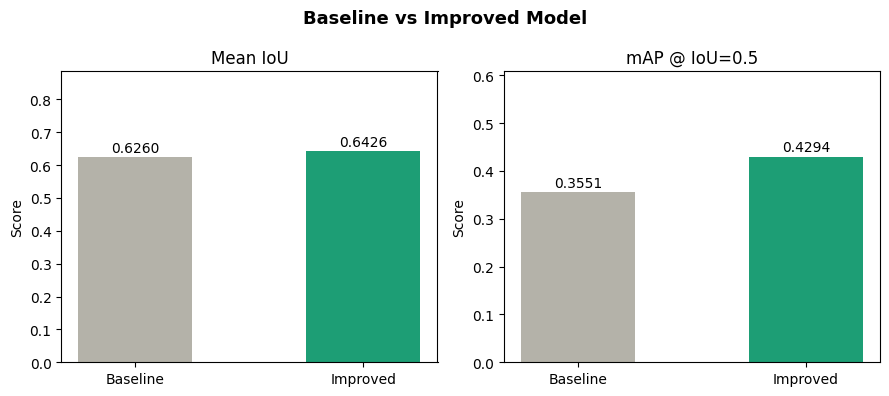

In [28]:
def evaluate_model(eval_model, eval_loader):
    eval_model.eval()
    iou_list, score_list, tp_list = [], [], []
    gt_total = 0

    with torch.no_grad():
        for imgs, tgts in eval_loader:
            imgs = [i.to(device) for i in imgs]
            outs = eval_model(imgs)
            for i in range(len(imgs)):
                preds  = outs[i]["boxes"].cpu().numpy()
                scores = outs[i]["scores"].cpu().numpy()
                gts    = tgts[i]["boxes"].numpy()
                gt_total += len(gts)
                for gt in gts:
                    best = max((compute_iou(p, gt) for p in preds), default=0)
                    iou_list.append(best)
                matched = set()
                for pred, sc in zip(preds, scores):
                    best_iou, best_j = 0, -1
                    for j, gt in enumerate(gts):
                        iou = compute_iou(pred, gt)
                        if iou > best_iou:
                            best_iou, best_j = iou, j
                    tp = 1 if best_iou >= 0.5 and best_j not in matched else 0
                    if tp: matched.add(best_j)
                    tp_list.append(tp)
                    score_list.append(sc)

    mean_iou_val = float(np.mean(iou_list)) if iou_list else 0.0
    mAP_val = 0.0
    if score_list and gt_total > 0:
        idx = np.argsort(-np.array(score_list))
        tp_arr = np.array(tp_list)[idx]
        fp_arr = 1 - tp_arr
        tp_c = np.cumsum(tp_arr)
        fp_c = np.cumsum(fp_arr)
        prec = tp_c / (tp_c + fp_c + 1e-6)
        rec  = tp_c / (gt_total + 1e-6)
        for k in range(len(prec) - 2, -1, -1):
            prec[k] = max(prec[k], prec[k+1])
        mAP_val = float(np.trapezoid(prec, rec))
    return mean_iou_val, mAP_val

print("Evaluating baseline model...")
base_iou, base_map = evaluate_model(baseline_model, baseline_val_loader)
print("Evaluating improved model...")
impr_iou, impr_map = evaluate_model(model, val_loader)

#before vs after comparison table and chart
print("\n" + "="*58)
print(f"{'Metric':<25} {'Baseline':>14} {'Improved':>14}")
print("-"*58)
print(f"{'Mean IoU':<25} {base_iou:>14.4f} {impr_iou:>14.4f}")
print(f"{'mAP @ IoU=0.5':<25} {base_map:>14.4f} {impr_map:>14.4f}")
print(f"{'Pretrained weights':<25} {'No':>14} {'Yes':>14}")
print(f"{'Data augmentation':<25} {'No':>14} {'Yes':>14}")
print(f"{'LR scheduler':<25} {'No':>14} {'StepLR':>14}")
print("="*58)

iou_delta = impr_iou - base_iou
map_delta = impr_map - base_map
print(f"\nImprovement -> IoU: {iou_delta:+.4f}  |  mAP: {map_delta:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (metric, bv, iv) in zip(axes, [
        ('Mean IoU', base_iou, impr_iou),
        ('mAP @ IoU=0.5', base_map, impr_map)]):
    bars = ax.bar(['Baseline', 'Improved'], [bv, iv],
                  color=['#B4B2A9', '#1D9E75'], width=0.5)
    for bar, val in zip(bars, [bv, iv]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(metric)
    ax.set_ylim(0, max(bv, iv) * 1.3 + 0.05)
    ax.set_ylabel('Score')
plt.suptitle('Baseline vs Improved Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [35]:
def show_predictions(model, dataset, device, idx=0, threshold=0.5):
    model.eval()

    img, target = dataset[idx]

    with torch.no_grad():
        prediction = model([img.to(device)])

    pred_boxes = prediction[0]["boxes"].cpu().numpy()
    scores     = prediction[0]["scores"].cpu().numpy()

    # img is (3, H, W) — take first channel for grayscale display
    img_np = img[0].cpu().numpy()
    img_np = (img_np * 255).astype(np.uint8)
    img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)

    for box, score in zip(pred_boxes, scores):
        if score >= threshold:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_np, (x1, y1), (x2, y2), (255, 0, 255), 2)
            cv2.putText(
                img_np,
                f"pneumonia {score:.2f}",
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 255),
                2
            )

    plt.imshow(img_np)
    plt.title("Predicted Output")
    plt.axis("off")
    plt.show()


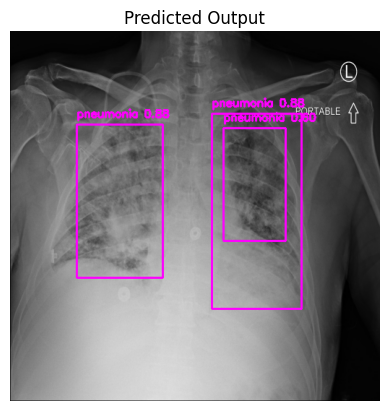

Mean IoU: 0.6426325
mAP at IoU=0.5: 0.4294360744066119


In [38]:
show_predictions(model, val_dataset, device, idx=4, threshold=0.5)
print("Mean IoU:", mean_iou)
print("mAP at IoU=0.5:", mAP)